# Baseline ML 

Este notebook replica el flujo simple del reel (cargar datos → features → split temporal → entrenar → evaluar):
- Datos desde `DataCleaner`/`preprocess_data`.
- Target **direction_2h** (0=DOWN, 1=FLAT, 2=UP).
- Split temporal + `TimeSeriesSplit` para selección de features.

> **Nota seguridad:** no hardcodear claves API en el repo. Usa variables de entorno.


In [ ]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data


In [ ]:
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol=["QQQ", "TLT", "VXX", "BNDX"],
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()

df = preprocess_data(df_raw, "qqq")

df.head()


c:\Users\koki2\Desktop\TRADING_ALG\src\data_cleaner.py:242: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["return"] = df["close"].pct_change()


,datetime,open_bndx,open_qqq,open_tlt,open_vxx,high_bndx,high_qqq,high_tlt,high_vxx,low_bndx,...,log_return_lag5,vol_rolling,rsi,macd,macd_signal,ema_9,ema_21,ema_50,ema_100,ema_200
0,2022-01-03 14:25:00+00:00,55.06,399.38,146.55,18.2100,55.060,399.41,146.600,18.30,55.06,...,-0.000275,0.000512,21.777778,-0.000707,-0.000518,399.110000,399.110000,399.110000,399.110000,399.110000
1,2022-01-03 14:30:00+00:00,55.03,399.05,146.41,18.2700,55.060,400.68,146.500,18.29,55.01,...,0.000601,0.000921,50.991501,-0.000474,-0.000509,399.372000,399.229091,399.161373,399.135941,399.123035
2,2022-01-03 14:35:00+00:00,55.02,400.44,146.36,18.1200,55.035,401.53,146.595,18.16,55.01,...,-0.000025,0.000983,60.246913,-0.000158,-0.000439,399.709600,399.395537,399.235829,399.174041,399.142308
3,2022-01-03 14:40:00+00:00,55.03,401.07,146.57,18.0701,55.040,401.26,146.800,18.15,55.03,...,0.000326,0.001024,57.547170,-0.000008,-0.000353,399.879680,399.501397,399.287757,399.201486,399.156414
4,2022-01-03 14:45:00+00:00,55.03,400.57,146.53,18.1100,55.050,400.75,146.940,18.56,55.03,...,-0.000050,0.001669,36.489076,-0.000359,-0.000354,399.547244,399.384679,399.245786,399.182001,399.147072


In [ ]:
from datetime import time
df = preprocess_data(df_raw, "qqq").copy()

HORIZON = 24  # 2h en velas de 5m
eps = 1e-12

# features
df["return"] = df["close"].pct_change(fill_method=None).fillna(0.0)
df["logret"] = np.log(df["close"].clip(lower=eps)).diff()

df["volatility"] = df["return"].rolling(5).std()
df["vol_5"]  = df["logret"].rolling(5).std()
df["vol_20"] = df["logret"].rolling(20).std()

for w in [5, 10, 20, 50, 100, 200]:
    df[f"ma_{w}"] = df["close"].rolling(w).mean()
    df[f"dist_ma_{w}"] = df["close"] / (df[f"ma_{w}"] + eps) - 1

if "rsi" not in df.columns:
    n = 14
    delta = df["close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    df["rsi"] = 100 - (100 / (1 + rs))

for sym in ["tlt", "vxx", "bndx"]:
    c = f"close_{sym}"
    r = f"ret_{sym}"
    if c in df.columns:
        df[r] = df[c].pct_change()

for lag in [1, 3, 6, 12]:
    df[f"return_lag{lag}"] = df["return"].shift(lag)
    df[f"rsi_lag{lag}"]    = df["rsi"].shift(lag)

# DEFINIMOS EL TARGET
# ORB 15m (3 velas de 5m) en NYfrom datetime import time

HORIZON = 24            # 2h en velas de 5m
ORB_BUF = 0.0002        # buffer para “confirmar” ruptura (ajusta luego)
eps = 1e-12

# --- NY session indexing ---
dt = pd.to_datetime(df["datetime"], utc=True)
ny = dt.dt.tz_convert("America/New_York")
df["_ny_date"] = ny.dt.date
df["_ny_time"] = ny.dt.time

session = (df["_ny_time"] >= time(9,30)) & (df["_ny_time"] < time(16,0))
df["_sess_n"] = np.nan
df.loc[session, "_sess_n"] = df.loc[session].groupby("_ny_date").cumcount()

# --- ORB 15m = 3 velas ---
mask_orb = df["_sess_n"].isin([0,1,2])
orb = df.loc[mask_orb].groupby("_ny_date").agg(
    orb_high=("high", "max"),
    orb_low=("low", "min")
)

df = df.drop(columns=["orb_high","orb_low"], errors="ignore")
df = df.join(orb, on="_ny_date")

def label_breakout_day(g):
    g = g.sort_values("datetime")
    out = pd.Series(np.nan, index=g.index)

    row = g[g["_sess_n"].eq(3)].head(1)  # 4ª vela (9:45)
    if row.empty:
        return out

    idx = row.index[0]
    oh = float(row["orb_high"].iloc[0]) * (1 + ORB_BUF)
    ol = float(row["orb_low"].iloc[0])  * (1 - ORB_BUF)

    future = g.loc[g.index > idx].head(HORIZON)
    if len(future) != HORIZON:
        return out

    hit = (future["high"].max() > oh) or (future["low"].min() < ol)
    out.loc[idx] = int(hit)
    return out

def label_dir_day(g):
    g = g.sort_values("datetime")
    out = pd.Series(np.nan, index=g.index)

    row = g[g["_sess_n"].eq(3)].head(1)
    if row.empty:
        return out

    idx = row.index[0]
    oh = float(row["orb_high"].iloc[0]) * (1 + ORB_BUF)
    ol = float(row["orb_low"].iloc[0])  * (1 - ORB_BUF)

    future = g.loc[g.index > idx].head(HORIZON)
    if len(future) != HORIZON:
        return out

    up = (future["high"].to_numpy() > oh)
    dn = (future["low"].to_numpy()  < ol)

    i_up = np.argmax(up) if up.any() else 10**9
    i_dn = np.argmax(dn) if dn.any() else 10**9

    if i_up < i_dn: out.loc[idx] = 1
    elif i_dn < i_up: out.loc[idx] = 0
    return out

df["y_break_2h"] = df.groupby("_ny_date", group_keys=False).apply(label_breakout_day)
df["y_dir_2h"]   = df.groupby("_ny_date", group_keys=False).apply(label_dir_day)

sig = df[df["_sess_n"].eq(3)].copy()
print("break_2h (solo info):")
print(sig["y_break_2h"].value_counts(normalize=True, dropna=True))
print("n days:", sig["y_break_2h"].notna().sum())

print("\ndir_2h (lo que vas a usar):")
sig_dir = sig.dropna(subset=["y_dir_2h"])
print(sig_dir["y_dir_2h"].value_counts(normalize=True))
print("n usable:", len(sig_dir))


c:\Users\koki2\Desktop\TRADING_ALG\src\data_cleaner.py:242: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["return"] = df["close"].pct_change()
C:\Users\koki2\AppData\Local\Temp\ipykernel_18076\934671902.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["y_break_2h"] = df.groupby("_ny_date", group_keys=False).apply(label_breakout_day)


break_2h (solo info):
y_break_2h
1.0    0.994018
0.0    0.005982
Name: proportion, dtype: float64
n days: 1003

dir_2h (lo que vas a usar):
y_dir_2h
1.0    0.506533
0.0    0.493467
Name: proportion, dtype: float64
n usable: 995


C:\Users\koki2\AppData\Local\Temp\ipykernel_18076\934671902.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["y_dir_2h"]   = df.groupby("_ny_date", group_keys=False).apply(label_dir_day)


ORB  | FULL  n=1000  win=0.500  avg=0.000461  maxDD=-0.073  sharpe~=1.238
ORB  | TRAIN n=800   win=0.497  avg=0.000474   maxDD=-0.073   sharpe~=1.246
ORB  | TEST  n=200   win=0.510  avg=0.000408   maxDD=-0.043   sharpe~=1.203
BH   | FULL  sharpe~=0.570  maxDD=-0.344


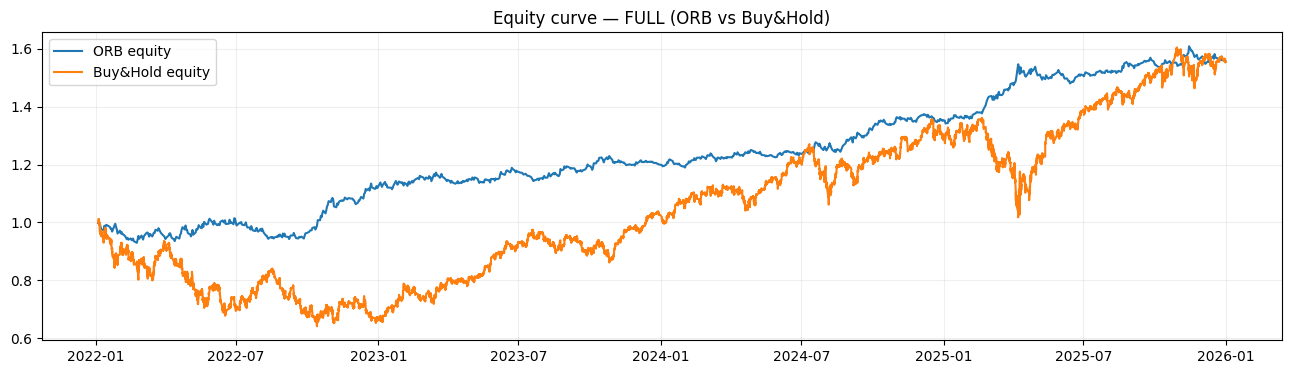

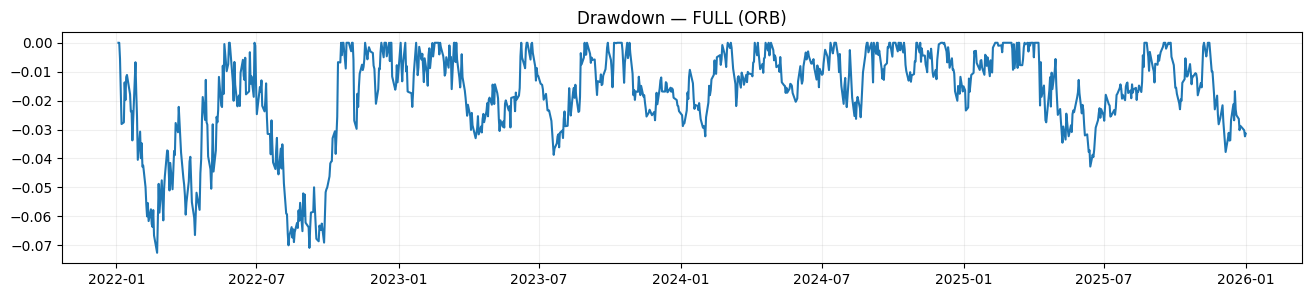

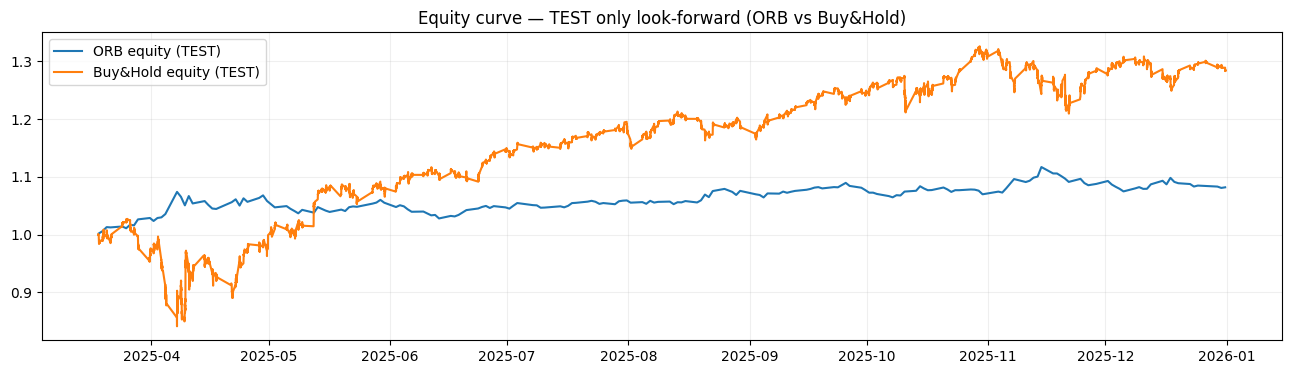

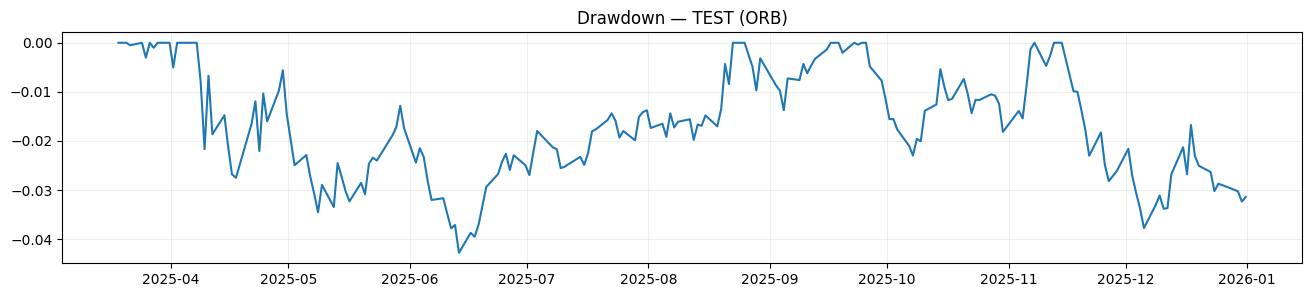

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== PARÁMETROS "REALES" (toca solo esto) ======
HORIZON = 24                 # 2h (5m bars)
RR = 2.0                     # SL:TP = 1:2
ORB_BUF = 0.0000             # 2 bps de confirmación (0.0 es más optimista)
SLIP = 0.00005                # 1 bp slippage (aplicado a fills)
COST = 0.0001                # 4 bps coste total por trade (round-trip aprox)
SPLIT = 0.8                  # only look-forward por días

# ====== CHEQUEOS ======
need = ["datetime","high","low","close","_ny_date","_sess_n","orb_high","orb_low"]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Faltan columnas en df: {missing}. Ejecuta antes la celda que crea ORB/labels."

df2 = df.sort_values("datetime").copy()

# ====== BACKTEST ORB OCO (1 trade/día, entrada en ruptura, SL=lado opuesto, TP=2R) ======
trades = []

for d, g in df2.groupby("_ny_date"):
    g = g.sort_values("datetime")

    row = g[g["_sess_n"].eq(3)].head(1)   # 4ª vela tras ORB
    if row.empty:
        continue
    idx0 = row.index[0]

    oh0 = row["orb_high"].iloc[0]
    ol0 = row["orb_low"].iloc[0]
    if pd.isna(oh0) or pd.isna(ol0):
        continue

    long_trg  = float(oh0) * (1 + ORB_BUF)
    short_trg = float(ol0) * (1 - ORB_BUF)

    future = g.loc[g.index > idx0].head(HORIZON)
    if len(future) != HORIZON:
        continue

    # --- encontrar 1ª entrada (OCO). Si toca ambos en misma vela -> skip ---
    ent_idx = None
    direction = None
    ent_px = None

    for ix, r in future.iterrows():
        hit_up = float(r["high"]) >= long_trg
        hit_dn = float(r["low"])  <= short_trg

        if hit_up and hit_dn:
            direction = None
            break
        if hit_up:
            ent_idx = ix
            direction = +1
            ent_px = long_trg * (1 + SLIP)      # long peor: más caro
            break
        if hit_dn:
            ent_idx = ix
            direction = -1
            ent_px = short_trg * (1 - SLIP)     # short peor: vendes más barato
            break

    if direction is None:
        continue

    # --- SL/TP 1:2 (SL al otro lado del ORB) ---
    if direction == +1:
        sl = short_trg
        risk = ent_px - sl
        if risk <= 0: 
            continue
        tp = ent_px + RR * risk
    else:
        sl = long_trg
        risk = sl - ent_px
        if risk <= 0:
            continue
        tp = ent_px - RR * risk

    # --- salida desde la vela de entrada (máximo HORIZON velas) ---
    after_entry = g.loc[g.index >= ent_idx].head(HORIZON)
    exit_idx = after_entry.index[-1]
    exit_px = float(after_entry.loc[exit_idx, "close"])
    reason = "time"

    def fill_exit(px, dirn):
        # aplica slippage adverso al cierre
        return px * (1 - SLIP) if dirn == +1 else px * (1 + SLIP)

    for ix, r in after_entry.iterrows():
        hi = float(r["high"])
        lo = float(r["low"])

        if direction == +1:
            hit_sl = lo <= sl
            hit_tp = hi >= tp
            if hit_sl and hit_tp:
                exit_px = sl * (1 - SLIP)
                exit_idx = ix
                reason = "sl_samebar"
                break
            if hit_sl:
                exit_px = sl * (1 - SLIP)
                exit_idx = ix
                reason = "sl"
                break
            if hit_tp:
                exit_px = tp * (1 - SLIP)
                exit_idx = ix
                reason = "tp"
                break
        else:
            hit_sl = hi >= sl
            hit_tp = lo <= tp
            if hit_sl and hit_tp:
                exit_px = sl * (1 + SLIP)
                exit_idx = ix
                reason = "sl_samebar"
                break
            if hit_sl:
                exit_px = sl * (1 + SLIP)
                exit_idx = ix
                reason = "sl"
                break
            if hit_tp:
                exit_px = tp * (1 + SLIP)
                exit_idx = ix
                reason = "tp"
                break

    if reason == "time":
        exit_px = fill_exit(exit_px, direction)

    ret = direction * (exit_px / ent_px - 1.0) - COST

    trades.append({
        "ny_date": d,
        "entry_dt": g.loc[ent_idx, "datetime"],
        "entry_px": ent_px,
        "dir": direction,
        "exit_dt": g.loc[exit_idx, "datetime"],
        "exit_px": exit_px,
        "reason": reason,
        "ret": ret
    })

trades = pd.DataFrame(trades).sort_values("entry_dt").reset_index(drop=True)
assert len(trades) > 0, "No hay trades. Revisa ORB_BUF/SLIP/COST o la construcción del ORB."

# ====== SPLIT only look-forward ======
days = trades["ny_date"].unique()
cut = int(len(days) * SPLIT)
cut_day = days[cut]

tr_tr = trades[trades["ny_date"] < cut_day].copy()
tr_te = trades[trades["ny_date"] >= cut_day].copy()

# ====== MÉTRICAS (equity, DD, sharpe) ======
def perf_from_rets(rets):
    eq = (1 + rets).cumprod()
    peak = eq.cummax()
    dd = eq/peak - 1
    mu = rets.mean()
    sd = rets.std(ddof=1) if len(rets) > 1 else np.nan
    sharpe = (np.sqrt(252) * mu / sd) if (sd and sd > 0) else np.nan
    return eq, dd, sharpe

eq_all, dd_all, sh_all = perf_from_rets(trades["ret"])
eq_tr,  dd_tr,  sh_tr  = perf_from_rets(tr_tr["ret"])
eq_te,  dd_te,  sh_te  = perf_from_rets(tr_te["ret"])

print(f"ORB  | FULL  n={len(trades)}  win={(trades['ret']>0).mean():.3f}  avg={trades['ret'].mean():.6f}  maxDD={dd_all.min():.3f}  sharpe~={sh_all:.3f}")
print(f"ORB  | TRAIN n={len(tr_tr)}   win={(tr_tr['ret']>0).mean():.3f}  avg={tr_tr['ret'].mean():.6f}   maxDD={dd_tr.min():.3f}   sharpe~={sh_tr:.3f}")
print(f"ORB  | TEST  n={len(tr_te)}   win={(tr_te['ret']>0).mean():.3f}  avg={tr_te['ret'].mean():.6f}   maxDD={dd_te.min():.3f}   sharpe~={sh_te:.3f}")

# ====== BUY & HOLD (mismo periodo) ======
start_dt = trades["entry_dt"].min()
end_dt   = trades["exit_dt"].max()

px = df2.loc[(df2["datetime"] >= start_dt) & (df2["datetime"] <= end_dt), ["datetime","close","_ny_date"]].copy()
px = px.sort_values("datetime")

# equity bh intradía (para plot bonito)
bh_eq = px["close"] / float(px["close"].iloc[0])

# equity bh “diaria” para sharpe comparable
bh_daily = px.groupby("_ny_date")["close"].last()
bh_rets = bh_daily.pct_change().dropna()
bh_eq_daily = (1 + bh_rets).cumprod()
bh_dd = bh_eq_daily / bh_eq_daily.cummax() - 1
bh_sh = (np.sqrt(252) * bh_rets.mean() / bh_rets.std(ddof=1)) if bh_rets.std(ddof=1) > 0 else np.nan

# split bh por cut_day
bh_daily_tr = bh_daily[bh_daily.index < cut_day]
bh_daily_te = bh_daily[bh_daily.index >= cut_day]
bh_rets_tr = bh_daily_tr.pct_change().dropna()
bh_rets_te = bh_daily_te.pct_change().dropna()

def sharpe_from_rets(r):
    sd = r.std(ddof=1)
    return (np.sqrt(252) * r.mean() / sd) if sd > 0 else np.nan

print(f"BH   | FULL  sharpe~={bh_sh:.3f}  maxDD={bh_dd.min():.3f}")

# ====== PLOTS (FULL) ======
plt.figure(figsize=(16,4))
plt.plot(trades["entry_dt"], eq_all, label="ORB equity")
plt.plot(px["datetime"], bh_eq.to_numpy(), label="Buy&Hold equity")
plt.title("Equity curve — FULL (ORB vs Buy&Hold)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(16,3))
plt.plot(trades["entry_dt"], dd_all, label="ORB drawdown")
plt.title("Drawdown — FULL (ORB)")
plt.grid(True, alpha=0.2)
plt.show()

# ====== PLOTS (TEST only look-forward) ======
plt.figure(figsize=(16,4))
plt.plot(tr_te["entry_dt"], eq_te, label="ORB equity (TEST)")
px_te = px[px["_ny_date"] >= cut_day]
bh_eq_te = px_te["close"] / float(px_te["close"].iloc[0])
plt.plot(px_te["datetime"], bh_eq_te.to_numpy(), label="Buy&Hold equity (TEST)")
plt.title("Equity curve — TEST only look-forward (ORB vs Buy&Hold)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(16,3))
plt.plot(tr_te["entry_dt"], dd_te, label="ORB drawdown (TEST)")
plt.title("Drawdown — TEST (ORB)")
plt.grid(True, alpha=0.2)
plt.show()


Combinaciones evaluadas: 180 / 180 (las demás no tenían trades suficientes)

TOP-10 (por Sharpe TEST):


,HORIZON,RR,ORB_BUF,SLIP,COST,n_tr,n_te,sh_tr,dd_tr,mu_tr,sh_te,dd_te,mu_te
0,36,2.5,0.0000,0.00005,0.0001,800,200,1.269833,-0.086428,0.000541,2.290861,-0.039782,0.000942
1,36,3.0,0.0000,0.00005,0.0001,800,200,1.126768,-0.107467,0.000479,2.197611,-0.039782,0.000958
2,36,3.0,0.0001,0.00005,0.0001,797,200,0.883640,-0.118487,0.000376,2.126763,-0.041993,0.000938
3,36,2.5,0.0001,0.00005,0.0001,797,200,1.118063,-0.083694,0.000482,2.095329,-0.041993,0.000866
4,36,2.5,0.0000,0.00010,0.0001,800,200,1.041036,-0.093431,0.000445,2.052987,-0.041128,0.000847
5,36,2.5,0.0000,0.00005,0.0002,800,200,1.035296,-0.093897,0.000441,2.047614,-0.041129,0.000842
6,36,1.0,0.0000,0.00005,0.0001,800,200,0.992868,-0.109971,0.000352,1.993203,-0.047556,0.000581
7,36,3.0,0.0000,0.00010,0.0001,800,200,0.912223,-0.114770,0.000388,1.982632,-0.041128,0.000867
8,36,3.0,0.0000,0.00005,0.0002,800,200,0.891339,-0.114767,0.000379,1.968202,-0.041129,0.000858
9,36,2.0,0.0000,0.00005,0.0001,800,200,1.306346,-0.091272,0.000541,1.964164,-0.039782,0.000734



MEJOR PARAMETRIZACIÓN (ganadora):
{'HORIZON': 36.0, 'RR': 2.5, 'ORB_BUF': 0.0, 'SLIP': 5e-05, 'COST': 0.0001, 'sh_te': 2.290861271403254, 'dd_te': -0.039781544928099266, 'mu_te': 0.0009417812911764054, 'n_te': 200.0}


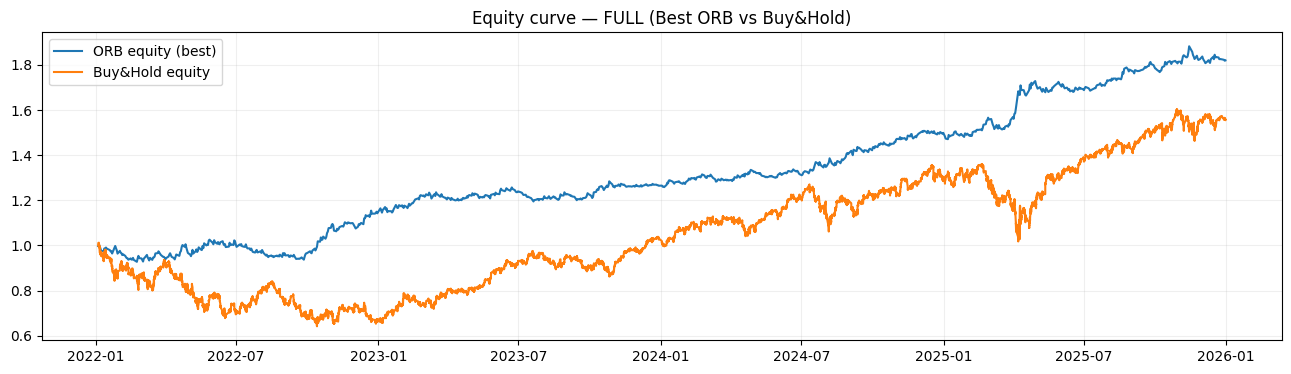

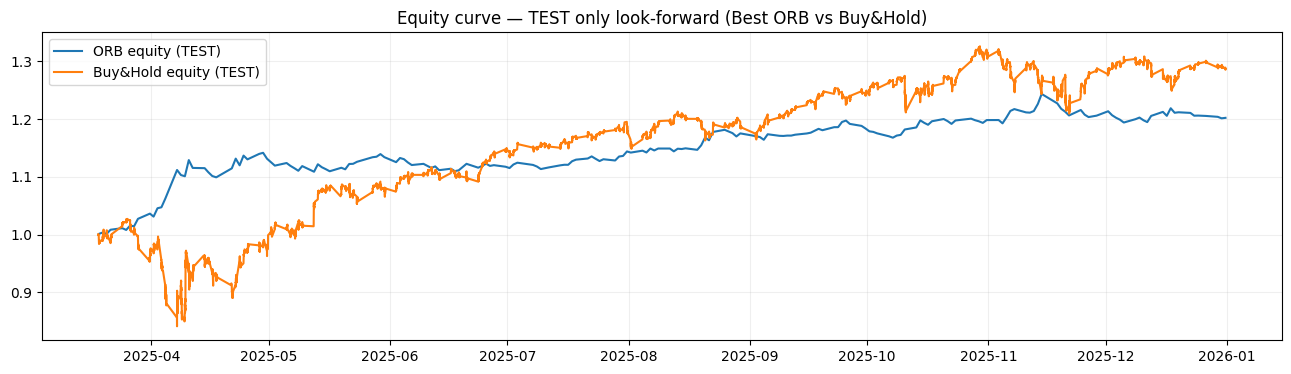

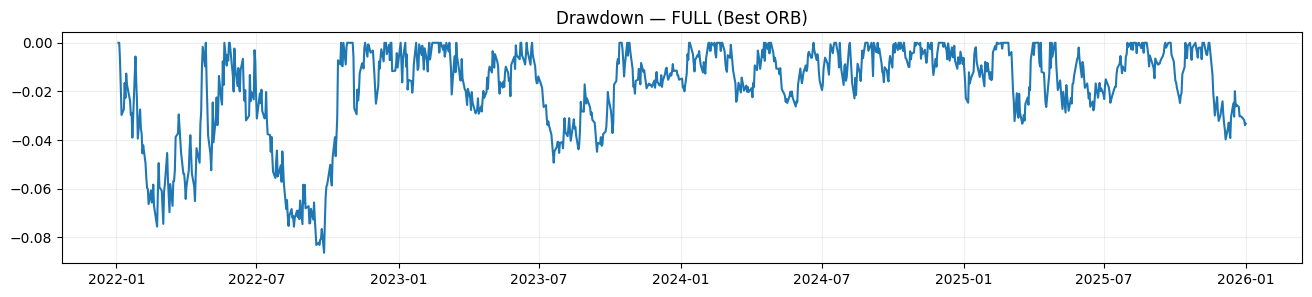

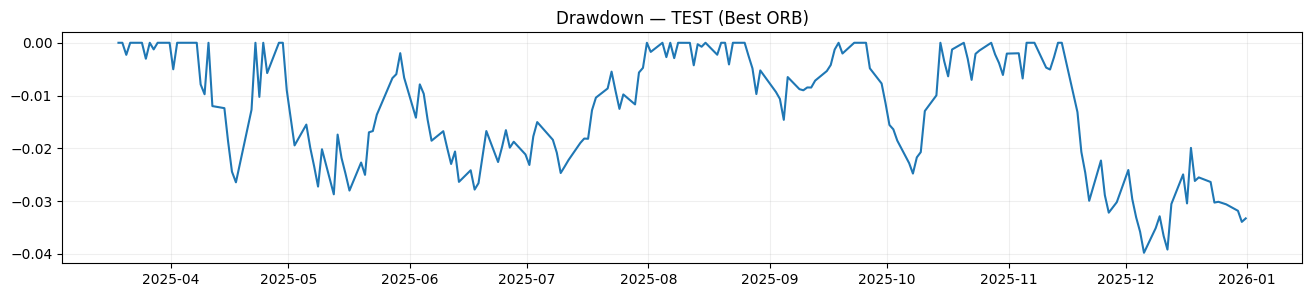

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== REQUIERE df con ORB ya calculado (orb_high/orb_low, _ny_date, _sess_n, datetime, high, low, close) ======
need = ["datetime","high","low","close","_ny_date","_sess_n","orb_high","orb_low"]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Faltan columnas en df: {missing}. Ejecuta antes la celda que construye ORB."

df2 = df.sort_values("datetime").copy()

# ====== GRID (ajusta si quieres hacerlo más “gigante”) ======
SPLIT = 0.8  # only look-forward por días

GRID = {
    "HORIZON": [12, 24, 36],                     # 1h, 2h, 3h
    "RR":      [1.0, 1.5, 2.0, 2.5, 3.0],         # TP = RR * riesgo
    "ORB_BUF": [0.0, 0.0001, 0.0002],             # 0, 1bp, 2bp
    "SLIP":    [0.00005, 0.0001],                 # 0.5bp, 1bp
    "COST":    [0.0001, 0.0002],                  # 1bp, 2bp
}

# ====== BACKTEST PARAMETRIZADO ======
def run_orb(df_in, HORIZON, RR, ORB_BUF, SLIP, COST):
    trades = []
    for d, g in df_in.groupby("_ny_date"):
        g = g.sort_values("datetime")

        row = g[g["_sess_n"].eq(3)].head(1)  # 4ª vela tras ORB
        if row.empty: 
            continue
        idx0 = row.index[0]

        oh0 = row["orb_high"].iloc[0]
        ol0 = row["orb_low"].iloc[0]
        if pd.isna(oh0) or pd.isna(ol0): 
            continue

        long_trg  = float(oh0) * (1 + ORB_BUF)
        short_trg = float(ol0) * (1 - ORB_BUF)

        future = g.loc[g.index > idx0].head(HORIZON)
        if len(future) != HORIZON:
            continue

        # entrada OCO
        ent_idx = None
        direction = None
        ent_px = None

        for ix, r in future.iterrows():
            hit_up = float(r["high"]) >= long_trg
            hit_dn = float(r["low"])  <= short_trg

            if hit_up and hit_dn:
                direction = None
                break
            if hit_up:
                ent_idx = ix
                direction = +1
                ent_px = long_trg * (1 + SLIP)   # long peor fill
                break
            if hit_dn:
                ent_idx = ix
                direction = -1
                ent_px = short_trg * (1 - SLIP)  # short peor fill
                break

        if direction is None:
            continue

        # SL al lado opuesto del ORB; TP=RR*riesgo
        if direction == +1:
            sl = short_trg
            risk = ent_px - sl
            if risk <= 0: 
                continue
            tp = ent_px + RR * risk
        else:
            sl = long_trg
            risk = sl - ent_px
            if risk <= 0:
                continue
            tp = ent_px - RR * risk

        after_entry = g.loc[g.index >= ent_idx].head(HORIZON)
        exit_idx = after_entry.index[-1]
        exit_px = float(after_entry.loc[exit_idx, "close"])
        reason = "time"

        def fill_exit(px, dirn):
            return px * (1 - SLIP) if dirn == +1 else px * (1 + SLIP)

        for ix, r in after_entry.iterrows():
            hi = float(r["high"]); lo = float(r["low"])

            if direction == +1:
                hit_sl = lo <= sl
                hit_tp = hi >= tp
                if hit_sl and hit_tp:          # conservador: SL si ambos en misma vela
                    exit_px = sl * (1 - SLIP); exit_idx = ix; reason = "sl_samebar"; break
                if hit_sl:
                    exit_px = sl * (1 - SLIP); exit_idx = ix; reason = "sl"; break
                if hit_tp:
                    exit_px = tp * (1 - SLIP); exit_idx = ix; reason = "tp"; break
            else:
                hit_sl = hi >= sl
                hit_tp = lo <= tp
                if hit_sl and hit_tp:
                    exit_px = sl * (1 + SLIP); exit_idx = ix; reason = "sl_samebar"; break
                if hit_sl:
                    exit_px = sl * (1 + SLIP); exit_idx = ix; reason = "sl"; break
                if hit_tp:
                    exit_px = tp * (1 + SLIP); exit_idx = ix; reason = "tp"; break

        if reason == "time":
            exit_px = fill_exit(exit_px, direction)

        ret = direction * (exit_px / ent_px - 1.0) - COST

        trades.append({
            "ny_date": d,
            "entry_dt": g.loc[ent_idx, "datetime"],
            "dir": direction,
            "ret": ret
        })

    if not trades:
        return None

    tr = pd.DataFrame(trades).sort_values("entry_dt").reset_index(drop=True)
    return tr

def perf(rets):
    eq = (1 + rets).cumprod()
    dd = eq / eq.cummax() - 1.0
    mu = rets.mean()
    sd = rets.std(ddof=1) if len(rets) > 1 else np.nan
    sh = (np.sqrt(252) * mu / sd) if (sd and sd > 0) else np.nan
    return float(mu), float(dd.min()), float(sh)

# ====== GRID SEARCH ======
results = []
total = len(GRID["HORIZON"])*len(GRID["RR"])*len(GRID["ORB_BUF"])*len(GRID["SLIP"])*len(GRID["COST"])
k = 0

for H in GRID["HORIZON"]:
    for RR in GRID["RR"]:
        for OB in GRID["ORB_BUF"]:
            for SLIP in GRID["SLIP"]:
                for COST in GRID["COST"]:
                    k += 1
                    tr = run_orb(df2, H, RR, OB, SLIP, COST)
                    if tr is None or len(tr) < 50:
                        continue

                    days = tr["ny_date"].unique()
                    cut = int(len(days) * SPLIT)
                    if cut < 50:
                        continue
                    cut_day = days[cut]
                    tr_tr = tr[tr["ny_date"] < cut_day]
                    tr_te = tr[tr["ny_date"] >= cut_day]
                    if len(tr_te) < 50:
                        continue

                    mu_te, dd_te, sh_te = perf(tr_te["ret"])
                    mu_tr, dd_tr, sh_tr = perf(tr_tr["ret"])

                    results.append({
                        "HORIZON": H, "RR": RR, "ORB_BUF": OB, "SLIP": SLIP, "COST": COST,
                        "n_tr": len(tr_tr), "n_te": len(tr_te),
                        "sh_tr": sh_tr, "dd_tr": dd_tr, "mu_tr": mu_tr,
                        "sh_te": sh_te, "dd_te": dd_te, "mu_te": mu_te,
                    })

res = pd.DataFrame(results)
assert len(res) > 0, "No salieron combinaciones válidas. Reduce fricción o amplía datos."

# ranking: max Sharpe TEST, tie-break por menor drawdown TEST (más cerca de 0)
res = res.sort_values(["sh_te", "dd_te"], ascending=[False, False]).reset_index(drop=True)

print(f"Combinaciones evaluadas: {len(res)} / {total} (las demás no tenían trades suficientes)")
print("\nTOP-10 (por Sharpe TEST):")
display(res.head(10))

best = res.iloc[0].to_dict()
print("\nMEJOR PARAMETRIZACIÓN (ganadora):")
print({k: best[k] for k in ["HORIZON","RR","ORB_BUF","SLIP","COST","sh_te","dd_te","mu_te","n_te"]})

# ====== PLOT del ganador vs Buy&Hold (FULL y TEST) ======
H = int(best["HORIZON"]); RR = float(best["RR"]); OB = float(best["ORB_BUF"]); SLIP = float(best["SLIP"]); COST = float(best["COST"])
tr_best = run_orb(df2, H, RR, OB, SLIP, COST)

days = tr_best["ny_date"].unique()
cut = int(len(days) * SPLIT)
cut_day = days[cut]
tr_te = tr_best[tr_best["ny_date"] >= cut_day].copy()

# equity
eq_full = (1 + tr_best["ret"]).cumprod()
eq_te   = (1 + tr_te["ret"]).cumprod()

# buy&hold (mismo periodo)
start_dt = tr_best["entry_dt"].min()
end_dt   = tr_best["entry_dt"].max()
px = df2.loc[(df2["datetime"] >= start_dt) & (df2["datetime"] <= end_dt), ["datetime","close","_ny_date"]].sort_values("datetime")
bh_eq = px["close"] / float(px["close"].iloc[0])

# test slice
px_te = px[px["_ny_date"] >= cut_day]
bh_eq_te = px_te["close"] / float(px_te["close"].iloc[0])

# plots
plt.figure(figsize=(16,4))
plt.plot(tr_best["entry_dt"], eq_full, label="ORB equity (best)")
plt.plot(px["datetime"], bh_eq.to_numpy(), label="Buy&Hold equity")
plt.title("Equity curve — FULL (Best ORB vs Buy&Hold)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(16,4))
plt.plot(tr_te["entry_dt"], eq_te, label="ORB equity (TEST)")
plt.plot(px_te["datetime"], bh_eq_te.to_numpy(), label="Buy&Hold equity (TEST)")
plt.title("Equity curve — TEST only look-forward (Best ORB vs Buy&Hold)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

# drawdown best
dd_full = eq_full / eq_full.cummax() - 1.0
dd_te_  = eq_te / eq_te.cummax() - 1.0

plt.figure(figsize=(16,3))
plt.plot(tr_best["entry_dt"], dd_full)
plt.title("Drawdown — FULL (Best ORB)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(16,3))
plt.plot(tr_te["entry_dt"], dd_te_)
plt.title("Drawdown — TEST (Best ORB)")
plt.grid(True, alpha=0.2)
plt.show()


In [ ]:
print(df["direction_2h"].value_counts(normalize=True))
print("n:", len(df))


direction_2h
0    0.615385
1    0.384615
Name: proportion, dtype: float64
n: 13


In [ ]:
features = [
    "close","volume","return","logret","vol_5","vol_20",
    "ma_5","ma_10","ma_20","ma_50","ma_100","ma_200",
    "dist_ma_5","dist_ma_10","dist_ma_20","dist_ma_50","dist_ma_100","dist_ma_200",
    "ret_tlt","ret_vxx","ret_bndx",
    "rsi","return_lag1","return_lag3","return_lag6","return_lag12",
    "rsi_lag1","rsi_lag3","rsi_lag6","rsi_lag12"
]

# qué features te faltan (por si algún exógeno no está)
missing = [c for c in features if c not in df.columns]
print("missing:", missing)

features_ok = [c for c in features if c in df.columns]

LEAK_COLS = ["direction_2h", "close_future", "fwd_logret", "thr"]

X = (
    df.select_dtypes(include=[np.number])
      .drop(columns=LEAK_COLS, errors="ignore")
)

y = df["direction_2h"].astype(int)



y.value_counts()


missing: []


direction_2h
1    33797
0    28109
Name: count, dtype: int64

In [ ]:
print("Clases:", y.value_counts())
print("Proporciones:", y.value_counts(normalize=True))

Clases: direction_2h
1    42953
0    36714
Name: count, dtype: int64
Proporciones: direction_2h
1    0.539157
0    0.460843
Name: proportion, dtype: float64


In [ ]:
df["return"] = df["close"].pct_change(fill_method=None).fillna(0.0)
X = df.select_dtypes(include=[np.number]).drop(columns=["close_future","direction_2h"], errors="ignore")
y = df["direction_2h"].astype(int)

selected_lstm = [
    # "close", 
    "volume",
    "return", "logret", "vol_20",
    "rsi", "return_lag3", "rsi_lag6",
    "dist_ma_20", "dist_ma_50", "dist_ma_100", "dist_ma_200",
    "ret_tlt","ret_vxx","ret_bndx"
]

features_ok = [c for c in selected_lstm if c in X.columns]
Xsel = X[features_ok]



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_features = ["rsi", "rsi_lag6"]
standard_features = ["close", "volume", "return", "logret", "vol_20", "return_lag3",
                     "dist_ma_20", "dist_ma_50", "dist_ma_100", "dist_ma_200",
                     "ret_tlt", "ret_vxx", "ret_bndx"]


scalers = {}
for col in minmax_features:
    scalers[col] = MinMaxScaler(feature_range=(-1, 1))  

for col in standard_features:
    scalers[col] = StandardScaler()

# Split + Scaler

In [ ]:
import numpy as np

LOOKBACK = 96

split = int(len(Xsel) * 0.8)

X_scaled_df = Xsel.copy()


for col in Xsel.columns:
    sc = scalers[col]                     
    sc.fit(Xsel[[col]].iloc[:split])     
    X_scaled_df[col] = sc.transform(Xsel[[col]])[:, 0]  

X_scaled = X_scaled_df.to_numpy(dtype=np.float32)

y_arr = y.to_numpy().astype(np.float32)


# Secuencias para la LSTM

In [ ]:
Xs, ys, idxs = [], [], []

for i in range(LOOKBACK, len(X_scaled)):
    if np.isnan(y[i]):      
        continue

    Xs.append(X_scaled[i-LOOKBACK+1:i+1])
    ys.append(y[i])
    idxs.append(i)

Xs = np.array(Xs, dtype=np.float32)
ys = np.array(ys, dtype=np.float32)
idxs = np.array(idxs)

train_mask = idxs < split
X_train, y_train = Xs[train_mask], ys[train_mask]
X_test,  y_test  = Xs[~train_mask], ys[~train_mask]


In [ ]:
print("Train y mean:", y_train.mean(), "n:", len(y_train))
print("Test  y mean:", y_test.mean(),  "n:", len(y_test))


Train y mean: 0.53355753 n: 63637
Test  y mean: 0.56313545 n: 15934


In [ ]:
X_small = X_train[:1024]
y_small = y_train[:1024]

m = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
          loss="binary_crossentropy",
          metrics=[tf.keras.metrics.AUC(name="auc")])

m.fit(X_small, y_small, epochs=30, batch_size=32, shuffle=False, verbose=0)
print("train:", m.evaluate(X_small, y_small, verbose=0))


train: [0.28704941272735596, 0.9623770713806152]


In [ ]:
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.keras.backend.clear_session()
tf.random.set_seed(42)

cut = int(len(X_train) * 0.9)
X_tr, y_tr = X_train[:cut], y_train[:cut]
X_val, y_val = X_train[cut:], y_train[cut:]

p = float(np.mean(y_tr))
p = np.clip(p, 1e-6, 1 - 1e-6)
bias = np.log(p / (1 - p))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train.shape[2])),
    tf.keras.layers.LayerNormalization(axis=-1),
    tf.keras.layers.SpatialDropout1D(0.35),
    tf.keras.layers.LSTM(256, dropout=0.35, recurrent_dropout=0.35),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(1, activation="sigmoid",
                          bias_initializer=tf.keras.initializers.Constant(bias))
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

rlr = ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2,
                        min_lr=1e-6, verbose=1)

es = EarlyStopping(monitor="val_auc", mode="max", patience=10, restore_best_weights=True)

BATCH_SIZE = 512
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=[rlr, es],
    verbose=1
)

res = model.evaluate(X_test, y_test, verbose=0)
print(dict(zip(model.metrics_names, res)))



Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 39s 409ms/step - accuracy: 0.5357 - auc: 0.5119 - loss: 0.6932 - val_accuracy: 0.5280 - val_auc: 0.4863 - val_loss: 0.6954 - learning_rate: 3.0000e-04
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 348ms/step - accuracy: 0.5410 - auc: 0.5214 - loss: 0.6900 - val_accuracy: 0.5294 - val_auc: 0.4990 - val_loss: 0.6931 - learning_rate: 3.0000e-04
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 31s 354ms/step - accuracy: 0.5408 - auc: 0.5316 - loss: 0.6890 - val_accuracy: 0.5292 - val_auc: 0.4811 - val_loss: 0.6937 - learning_rate: 3.0000e-04
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5196 - auc: 0.5446 - loss: 0.6922
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
87/87 ━━━━━━━━━━━━━━━━━━━━ 31s 358ms/step - accuracy: 0.5425 - auc: 0.5295 - loss: 0.6888 - val_accuracy: 0.5294 - val_auc: 0.4941 - val_loss: 0.6928 - learning_rate: 3.0000e-04
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 31s 360ms/step - accuracy: 0.5413 - auc:

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import roc_auc_score
p_val = model.predict(X_val, batch_size=1024).ravel()
print("VAL auc:", roc_auc_score(y_val, p_val))
print("VAL auc_flip:", roc_auc_score(y_val, 1 - p_val))


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 568ms/step
VAL auc: 0.4983693496882445
VAL auc_flip: 0.5016306503117555


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ====================== PLOT DEL AUC ======================
plt.figure(figsize=(10, 5))

plt.plot(history.history['auc'], label='AUC Entrenamiento', linewidth=2)
plt.plot(history.history['val_auc'], label='AUC Validación', linewidth=2)

plt.title('Evolución del AUC durante el entrenamiento', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('AUC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ====================== MATRIZ DE CONFUSIÓN ======================
# Predicciones en test
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype("int32").ravel()   # shape (n_samples,)

# Matriz
cm = confusion_matrix(y_test, y_pred)

# Visualización bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Negativo (0)', 'Positivo (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión - Test', fontsize=14)
plt.grid(False)
plt.show()

# Bonus: métricas de test (para que las veas también en texto)
from sklearn.metrics import classification_report
print("\n=== Reporte de clasificación en Test ===")
print(classification_report(y_test, y_pred, digits=4))